# 07. 시계열 기법: SARIMAX와 구조적 시계열

시계열 기법에도 외부 요인(프로모션, 할인 등)을 충분히 넣을 수 있습니다(`exog`).

| 기법 | 핵심 아이디어 |
|---|---|
| **SARIMAX** | 요인 효과 + "지난주에 잘 팔렸으면 이번 주도 잘 팔린다"는 관성(AR) 항 |
| **구조적 시계열** (Unobserved Components) | 요인 효과 + **시간에 따라 변하는 기본 수요**(레벨·추세) |

**요인 수의 제약은 기법이 아니라 데이터 양**입니다. 104주면 어떤 기법이든 요인 5~10개가 현실적 한계입니다.

**시계열 기법 사용 시 주의**
1. **미래 값이 필요**: 다음 주를 예측하려면 다음 주 프로모션 계획, 기온 예보 등이 있어야 합니다.
2. **설명력 손실 가능**: 관성(AR) 항이 요인 효과의 일부를 가져갈 수 있습니다.

In [1]:
import sys, warnings
sys.path.append("../src")
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib  # 한글 글꼴
from common import *
plt.rcParams["figure.dpi"] = 110
df = load_data()
y = df.sellout.values.astype(float)
print(df.shape)

(104, 8)


In [2]:
FOLD_STARTS, FOLD_LEN = [72, 80, 88, 96], 8   # 앞부분으로 학습 → 다음 8주 예측, 4번 반복

def time_series_cv(fit_predict):
    """fit_predict(train_idx) → 전체 기간 예측. 모델이 보지 못한 다음 8주의 MAPE 평균"""
    errs = []
    for s0 in FOLD_STARTS:
        tr, te = np.arange(s0), np.arange(s0, min(s0 + FOLD_LEN, len(df)))
        errs.append(mape(y[te], fit_predict(tr)[te]))
    return np.mean(errs), np.round(errs, 1)

In [3]:
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

t = np.arange(len(df), dtype=float)
exog_names = ["s1", "c1", "할인", "프로모션", "광고", "공휴일", "기온", "결품"]
X = np.column_stack([
    np.sin(2*np.pi*t/52), np.cos(2*np.pi*t/52), df.discount_pct, df.promo,
    np.log1p(adstock(df.ad_spend.values, 0.6)), df.holiday, df.temp - df.temp.mean(), df.stockout_days,
]).astype(float)

def sarimax_fit(tr):
    return sm.tsa.SARIMAX(y[tr], exog=X[tr], order=(1, 0, 0), trend="ct").fit(disp=False, maxiter=2000)  # 반복을 충분히 줘야 수렴

def sts_fit(tr):
    return sm.tsa.UnobservedComponents(y[tr], level="local linear trend", exog=X[tr]).fit(disp=False, maxiter=500)

def predict_with(fit):
    def f(tr):
        m = fit(tr)
        k = len(tr)
        p = np.full(len(df), np.nan)
        p[k:] = m.forecast(len(df) - k, exog=X[k:])   # 미래 요인 값(X[k:])을 알고 있다고 가정
        return p
    return f

res = {}
for name, fit in [("SARIMAX (추세+AR1+요인)", sarimax_fit), ("구조적 시계열", sts_fit)]:
    m = fit(np.arange(len(df)))
    names = m.param_names
    get = lambda nm: m.params[names.index(nm)]
    pref = "beta.x" if name == "구조적 시계열" else "x"
    coefs = {exog_names[j]: get(f"{pref}{j+1}") for j in range(len(exog_names))}
    cv, folds = time_series_cv(predict_with(fit))
    res[name] = dict(새데이터MAPE=round(cv, 1), **{k: round(v, 1) for k, v in coefs.items() if k not in ("s1", "c1")})
    if name.startswith("SARIMAX"):
        print(f"관성(AR1) 계수: {get('ar.L1'):.2f}  ← 지난주 판매 흐름이 이번 주에 이어지는 정도")
pd.DataFrame(res).T

관성(AR1) 계수: 0.22  ← 지난주 판매 흐름이 이번 주에 이어지는 정도


,새데이터MAPE,할인,프로모션,광고,공휴일,기온,결품
SARIMAX (추세+AR1+요인),3.0,13.1,280.0,62.9,178.3,-1.1,-88.4
구조적 시계열,3.0,13.1,268.4,59.6,168.0,-5.4,-90.5


In [4]:
truth = dict(할인=14, 프로모션=260, 공휴일=180, 기온=-6, 결품=-95)
tab = pd.DataFrame(res).T[["새데이터MAPE"] + list(truth)]
tab.loc["정답"] = [np.nan] + list(truth.values())
tab

,새데이터MAPE,할인,프로모션,공휴일,기온,결품
SARIMAX (추세+AR1+요인),3.0,13.1,280.0,178.3,-1.1,-88.4
구조적 시계열,3.0,13.1,268.4,168.0,-5.4,-90.5
정답,NaN,14.0,260.0,180.0,-6.0,-95.0


## 구조적 시계열: 기본 수요가 어떻게 움직였나

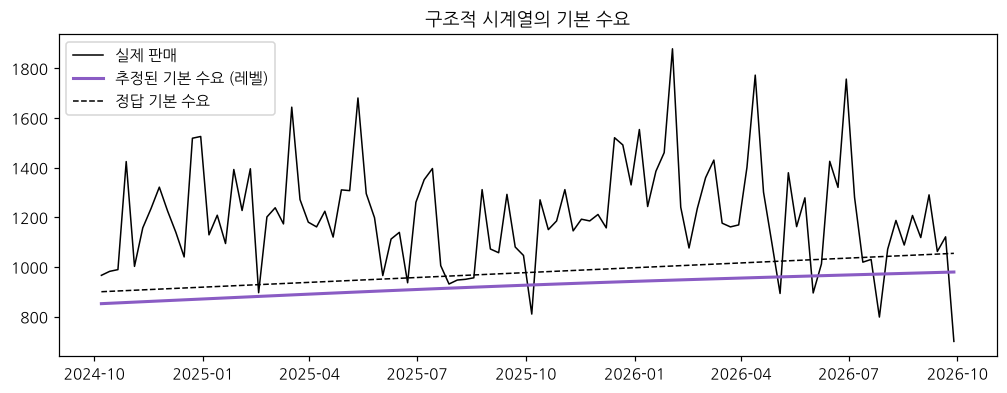

In [5]:
m = sts_fit(np.arange(len(df)))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(df.week, y, color="black", lw=1, label="실제 판매")
ax.plot(df.week, m.level.smoothed, color="#8a5cc4", lw=2, label="추정된 기본 수요 (레벨)")
ax.plot(df.week, 900 + 1.5 * t, "k--", lw=1, label="정답 기본 수요")
ax.legend(); ax.set_title("구조적 시계열의 기본 수요");

## 결과 해석
- **구조적 시계열**은 선형 회귀와 **거의 같은 결과**입니다. 이 가상 데이터의 기본 수요는 일정하게 오르기만 해서, "기본 수요가 자유롭게 변한다"는 장점이 쓰일 일이 없었습니다.
  실제 데이터에서 경쟁사 진입, 유통 채널 변화 등으로 기본 수요가 들쭉날쭉하다면 선형 회귀보다 확실히 나아집니다.
- **SARIMAX**는 **기온 효과를 거의 0으로** 잡았습니다(정답 −6). 관성(AR) 항과 계절 항이 기온의 몫을 가져간 것으로, 예측은 되지만 설명력이 떨어진 예입니다.
- SARIMAX는 최적화 반복 횟수가 부족하면 수렴하지 못하고 전혀 다른 계수를 내놓습니다(`maxiter=2000` 설정 이유). 결과가 불안정하면 시작값·반복 횟수를 꼭 확인하세요.

> 사실 01의 선형 회귀와 06의 MMM도 추세·계절성을 넣었기 때문에 이미 **"요인을 넣은 시계열 회귀"**의 일종입니다.
> 시계열 기법은 대체재라기보다, 기본 수요가 불안정하거나 미래 예측이 주목적일 때 꺼내 쓰는 업그레이드입니다.